# Task 1 : TITANIC SURVIVAL PREDICTION


In [6]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
# Load Dataset
data=pd.read_csv("Titanic-Dataset.csv")
print(data.shape)

print(data.head(5))
print(data.info())

(891, 12)
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN    

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


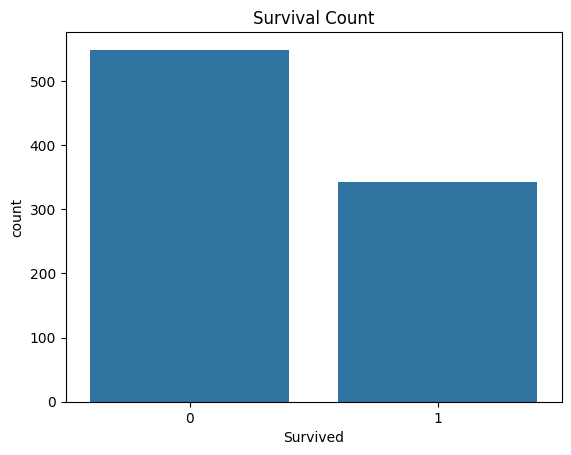

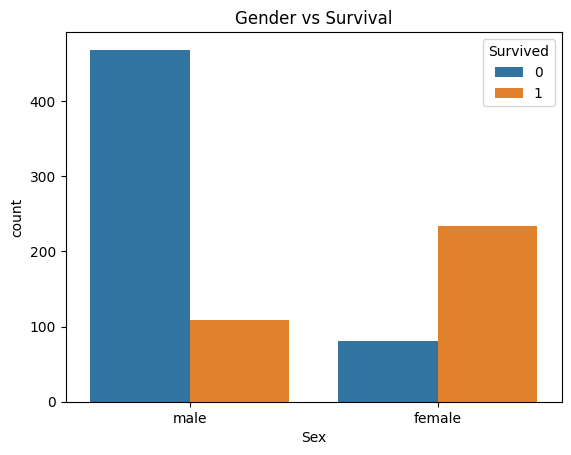

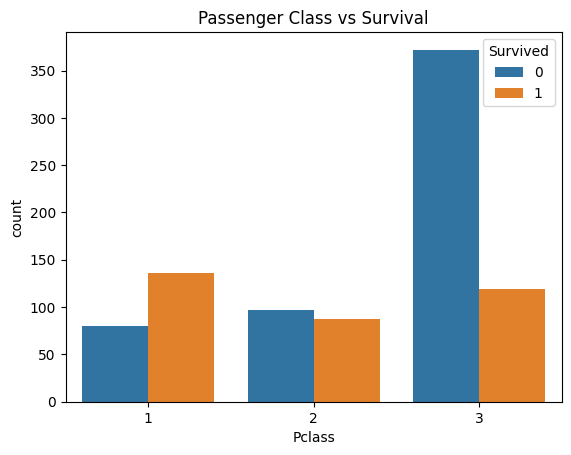


Survival count:
Survived
0    549
1    342
Name: count, dtype: int64

Survival rate:
Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


In [8]:
# Basic Exploratory Data Analysis (EDA)

print(data.isnull().sum())

# Survival Count
sns.countplot(x="Survived", data=data)
plt.title("Survival Count")
plt.show()

# Gender vs Survival
sns.countplot(x="Sex", hue="Survived", data=data)
plt.title("Gender vs Survival")
plt.show()

# Passenger Class vs Survival
sns.countplot(x="Pclass", hue="Survived", data=data)
plt.title("Passenger Class vs Survival")
plt.show()

print("\nSurvival count:")
print(data['Survived'].value_counts())

print("\nSurvival rate:")
print(data['Survived'].value_counts(normalize=True) * 100)

In [10]:
# Data Cleaning & Preprocessing

cols = [
    'Survived',
    'Pclass',
    'Sex',
    'Age',
    'SibSp',
    'Parch',
    'Fare',
    'Embarked'
]

data = data[cols].copy()

# Handling Missing Values

# Fill missing Age values using median
data['Age'] = data['Age'].fillna(data['Age'].median())

# Fill missing Embarked values using mode
data['Embarked'] = data['Embarked'].fillna(
    data['Embarked'].mode()[0]
)

# Encoding Categorical Data

# Encoding 'Sex' column
# male = 0 , female = 1

data['Sex'] = data['Sex'].map({
    'male': 0,
    'female': 1
})

# One-Hot Encoding for Embarked column
data = pd.get_dummies(
    data,
    columns=['Embarked'],
    drop_first=True
)

# Checking Final Cleaned Data
print(data.head())

print("\nRemaining Missing Values:\n")

print(data.isnull().sum())


   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked_Q  Embarked_S
0         0       3    0  22.0      1      0   7.2500       False        True
1         1       1    1  38.0      1      0  71.2833       False       False
2         1       3    1  26.0      0      0   7.9250       False        True
3         1       1    1  35.0      1      0  53.1000       False        True
4         0       3    0  35.0      0      0   8.0500       False        True

Remaining Missing Values:

Survived      0
Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Embarked_Q    0
Embarked_S    0
dtype: int64


In [27]:
# Splitting Data and Building Logistic Regression Model

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Defining Features (X) and Target Variable (y)
X = data.drop("Survived", axis=1)
y = data["Survived"]

# Splitting Dataset into Training and Testing Data
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42
)

# Creating Logistic Regression Model
model = LogisticRegression(
    max_iter=1000
)

# Training the Model
model.fit(X_train, y_train)

# Predicting Survival Values
y_pred = model.predict(X_test)

# Calculating Accuracy Score
accuracy = accuracy_score(y_test, y_pred)

print("Logistic Regression Model Accuracy :",
      round(accuracy * 100, 2), "%")

Logistic Regression Model Accuracy : 81.01 %


Model Accuracy : 81.01 %


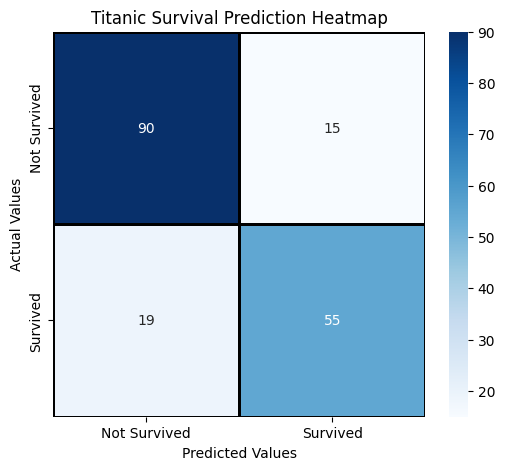


Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



In [30]:
# Model Evaluation & Confusion Matrix

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Accuracy Score
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy :",
      round(accuracy * 100, 2), "%")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
# Figure Size
plt.figure(figsize=(6,5))

# Heatmap
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    linewidths=1,
    linecolor='black',
    xticklabels=["Not Survived", "Survived"],
    yticklabels=["Not Survived", "Survived"]
)

# Titles and Labels
plt.title("Titanic Survival Prediction Heatmap")
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
# Show Plot
plt.show()

# Classification Report
print("\nClassification Report:\n")
print(classification_report(
    y_test,
    y_pred,
    digits=2
))

# Conclusion
The Logistic Regression model successfully predicted Titanic passenger survival.
This model achieved good accuracy for survival prediction based on passenger information.